# Model: Segmenters (Stage 2)

Second stage of the two-stage image-recognition pipeline: identifies the region of a product photo that actually shows the product's color, so a color value can be extracted from just that region. Product photos vary a lot by presentation type (a bullet tip, a liquid applicator wand, a flat swatch, a sealed container, and so on), so one segmenter can't handle all of them well; this notebook trains four separate U-Net segmenters, one per group of visually similar types. Reads `data/annotations/labels.csv`, which 06_a already produced, so this notebook does no data preparation of its own. Each segmenter trains on 100% of the training set (`labels.csv`, built for coverage and oversampled for scarce categories) and is evaluated against the separate, independently-sampled validation set from `04_b_validation_annotation_image.ipynb` (`labels_val.csv`).

**Segmenters:** U-Nets (ResNet-18 encoder, ImageNet pretrained) trained per class:
- `bullet` + `liquid` + `pencil` → `unet_segmenter.pth`
- `closed` (transparent containers) → `unet_segmenter_other.pth`
- `swatch` → `unet_swatch.pth`
- `lips` → `unet_lips.pth`, warm-started from the combined segmenter like `closed` was; trained on all 16 de-duplicated examples (started at 3 examples with no validation possible at all)
- `unclassifiable` has no segmenter, since there's nothing to extract from either underlying case.

**Inputs:** `data/annotations/labels.csv`, `data/annotations/masks/` (both written by [`06_a_model_classifier.ipynb`](06_a_model_classifier.ipynb)); `data/annotations/labels_val.csv` and `data/img/original_clean/` (04_b, for the post-training IoU check)

**Outputs:** `models/unet_segmenter.pth`, `models/unet_segmenter_other.pth`, `models/unet_swatch.pth`, `models/unet_lips.pth`, `notebooks/segmentation_results_log.csv`

In [1]:
import os
import sys
import hashlib
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import segmentation_models_pytorch as smp
warnings.filterwarnings('ignore')

SEED = 42

def seed_everything(seed=SEED):
    """Re-seed every RNG this notebook draws from. Called once here and again
    right before each training loop below, since augmentation (SegDatasetAny) uses
    Python's random module, which torch.manual_seed does not cover, and without
    re-seeding per stage, results drift depending on how many random draws
    happened earlier in the run."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

seed_everything()

# Resolve project paths relative to BASE, regardless of whether the notebook's
# cwd is the repo root or notebooks/ (works either way it's launched).
BASE = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, BASE)

DATA       = os.path.join(BASE, 'data', 'processed')
IMG        = os.path.join(BASE, 'data', 'img')
ANN_DIR    = os.path.join(BASE, 'data', 'annotations')
MODELS_DIR = os.path.join(BASE, 'models')
IMG_SAMPLE = os.path.join(IMG, 'annotation_sample')
IMG_CLOSED = os.path.join(IMG, 'annotation_sample_closed')
IMG_DIRS   = [IMG_SAMPLE, IMG_CLOSED]

os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}  |  seed: {SEED}')

def find_image(img_name, img_dirs=IMG_DIRS):
    """Return the first existing path for img_name across img_dirs, or None
    if it isn't found in any of them."""
    for d in img_dirs:
        p = os.path.join(d, img_name)
        if os.path.exists(p):
            return p
    return None


device: mps  |  seed: 42


## 1. Load Annotated Data

In [ ]:
# training set
labels_df = pd.read_csv(os.path.join(ANN_DIR, 'labels.csv'))
print(f'{len(labels_df)} labeled images loaded from data/annotations/labels.csv (written by 06_a_model_classifier.ipynb)')
print(labels_df['label'].value_counts())


392 labeled images loaded from data/annotations/labels.csv (written by 06_a_model_classifier.ipynb)
label
swatch            127
bullet             83
liquid             60
closed             47
pencil             29
unclassifiable     28
lips               18
Name: count, dtype: int64


In [ ]:
# validation set
labels_val_df = pd.read_csv(os.path.join(ANN_DIR, 'labels_val.csv'))
VAL_IMG_DIR = os.path.join(IMG, 'original_clean')
print(f'{len(labels_val_df)} validation images loaded from data/annotations/labels_val.csv (04_b)')
print(labels_val_df['label'].value_counts())


480 validation images loaded from data/annotations/labels_val.csv (04_b)
label
swatch            170
bullet            127
liquid            103
unclassifiable     33
pencil             24
closed             12
lips               11
Name: count, dtype: int64


## 2. Stage 2: Color Region Segmenter

This section fits one U-Net segmenter (ResNet-18 encoder, ImageNet pretrained) per group of presentation types, trained to output a binary mask (1 = color region, 0 = background) at 256×256.

The following sections each fit one segmenter:
- **2a**: `bullet` + `liquid` + `pencil`
- **2b**: `closed`
- **2d**: `swatch`
- **2e**: `lips`

### Design Decisions

**Training set vs. validation set.** `labels.csv` was built for coverage and to oversample scarce categories (03_c's Rounds 3-5 tripled `pencil` and grew `lips`/`unclassifiable` specifically), which is good for training but not representative of the real image distribution. `04_a`/`04_b` built a separate, independently-sampled validation set (`labels_val.csv`) for exactly that reason, so each segmenter here trains on 100% of the training set and is evaluated once, afterward, against the real validation set:

| Segmenter | Train N | Validation N | Validation IoU |
|---|---|---|---|
| `bullet`/`liquid`/`pencil` | 171 | 254 | 0.724 |
| `closed` | 39 | 12 | 0.734 |
| `swatch` | 123 | 170 | 0.884 |
| `lips` | 16 | 11 | 0.843 |

**Rotation augmentation (±45°) for all four models.** Evaluating early segmenters against the validation set turned up bullet/liquid images shot at an unusually steep ~45° angle that the original ±15° rotation range missed almost entirely, predicting an empty mask for them. Widening to ±45° let the model recognize these steep-angle shots too, so more of the validation images ended up with a real predicted mask instead of an empty one. `rotation_range=45` is now the default for `train_seg_model` and every stage below.

### Stage 2a: Color Region Segmenter for `bullet`, `liquid`, and `pencil`

In [ ]:
IMG_SIZE_SEG = 256

# Preprocessing shared by every segmenter below: resize + ImageNet
# normalization for the image, nearest-neighbor resize for the mask (keeps it
# binary instead of blurring 0/1 edges).
seg_img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
seg_mask_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

# bullet, liquid, and pencil are visually similar enough (a hand-held product
# against a plain background) to share one segmenter — see Stage 2a below.
SEG_CLASSES = {'bullet', 'liquid', 'pencil'}

In [5]:
def build_segmenter():
    """ResNet-18-encoder U-Net with a single output channel: a binary
    color-region mask (1 = color visible, 0 = background)."""
    return smp.Unet(
        encoder_name='resnet18',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
    )

def batch_iou(logits, masks, threshold=0.5):
    """Mean intersection-over-union for a batch, thresholding the sigmoid of
    logits at `threshold` to get a binary predicted mask."""
    pred = (torch.sigmoid(logits) > threshold).float()
    inter = (pred * masks).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
    return (inter / (union + 1e-6)).mean().item()


In [6]:
# Rows usable for the combined segmenter: right label, image found on disk,
# and a real hand-drawn mask exists (not just a label).
seg_train_df = labels_df[labels_df['label'].isin(SEG_CLASSES) & labels_df['img_name_disk'].notna()
                          & labels_df['mask_path'].apply(os.path.exists)]
print(f'Seg train: {len(seg_train_df)}  (100% of eligible data, no internal val split)')

seg_ckpt = os.path.join(MODELS_DIR, 'unet_segmenter.pth')


Seg train: 171  (100% of eligible data, no internal val split)


In [7]:
# Shared segmentation helpers used by all four stages below: a dataset that
# accepts any label subset (with optional synchronized image+mask
# augmentation) and a generic U-Net training loop.
import random

class SegDatasetAny(Dataset):
    """Like SegDataset but accepts any label subset, with optional synchronized
    augmentation. Rows without a real drawn mask are excluded, not padded with a
    blank one: a blank mask would wrongly teach the model 'no color here' for an
    unannotated image that may well have a visible color region."""
    def __init__(self, df, augment=False, rotation_range=45):
        self.df      = df[df['img_name_disk'].notna()
                        & df['mask_path'].apply(os.path.exists)].reset_index(drop=True)
        self.augment = augment
        self.rotation_range = rotation_range

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        mp   = row['mask_path']
        mask = Image.open(mp).convert('L') if os.path.exists(mp) else Image.new('L', img.size, 0)

        if self.augment:
            # Synchronized flip/rotation: the same transform is applied to
            # the image and its mask so they stay pixel-aligned.
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_TOP_BOTTOM)
                mask = mask.transpose(Image.FLIP_TOP_BOTTOM)
            angle = random.uniform(-self.rotation_range, self.rotation_range)
            img  = img.rotate(angle)
            mask = mask.rotate(angle)

        return seg_img_tf(img), (seg_mask_tf(mask) > 0.5).float()

def train_seg_model(train_df, val_df, ckpt_path, n_epochs=20, augment=False, rotation_range=45):
    """If val_df is None, trains on 100% of train_df for the fixed epoch
    schedule and saves the final checkpoint unconditionally, no internal
    validation split, since real segmenter quality is checked afterward
    against labels_val.csv (see eval_iou_on_val below) instead."""
    train_ds = SegDatasetAny(train_df, augment=augment, rotation_range=rotation_range)
    val_ds   = SegDatasetAny(val_df, augment=False) if val_df is not None else None
    model    = build_segmenter().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    opt       = torch.optim.Adam(model.parameters(), lr=1e-4)
    best_iou  = 0.0
    for epoch in range(n_epochs):
        # Standard supervised loop: forward pass, BCE loss against the
        # ground-truth mask, backprop.
        model.train()
        for imgs, masks in DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            loss = criterion(model(imgs), masks)
            opt.zero_grad(); loss.backward(); opt.step()
        if val_ds is not None:
            # Only used when val_df is explicitly passed (not the case for
            # any of the four segmenters below); tracks the best-IoU checkpoint.
            model.eval()
            val_ious = []
            with torch.no_grad():
                for imgs, masks in DataLoader(val_ds, batch_size=16, num_workers=0):
                    val_ious.append(batch_iou(model(imgs.to(DEVICE)), masks.to(DEVICE)))
            mean_iou = np.mean(val_ious)
            print(f'  epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
            if mean_iou > best_iou:
                best_iou = mean_iou
                torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
    if val_ds is None:
        torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
        print(f'Trained {n_epochs} epochs on 100% of data  \u2192  {ckpt_path}')
    else:
        print(f'Best IoU: {best_iou:.4f}  \u2192  {ckpt_path}')
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)['model_state_dict'])
    model.eval()
    return model

def eval_iou_on_val(model, val_df, labels):
    """Real IoU on the independent validation set (labels_val.csv). See the
    Design Decisions note above for why segmenters train on 100% of their
    data instead of holding out an internal split."""
    if isinstance(labels, str):
        labels = {labels}
    subset = val_df[val_df['label'].isin(labels) & val_df['img_name_disk'].notna()
                     & val_df['mask_path'].apply(os.path.exists)]
    ious = []
    for _, row in subset.iterrows():
        img_path = find_image(row['img_name_disk'], img_dirs=(VAL_IMG_DIR,))
        if img_path is None:
            continue
        img = Image.open(img_path).convert('RGB')
        x = seg_img_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pred = (torch.sigmoid(model(x)) > 0.5).float().cpu().numpy()[0, 0]
        gt = (np.array(Image.open(row['mask_path']).convert('L')) > 127).astype(np.uint8)
        # Predicted mask is always IMG_SIZE_SEG square; the on-disk ground-truth
        # mask matches the original image dimensions, so resize before comparing.
        if pred.shape != gt.shape:
            pred = np.array(Image.fromarray((pred * 255).astype(np.uint8)).resize(
                gt.shape[::-1], Image.NEAREST)) // 255
        inter = np.logical_and(pred, gt).sum()
        union = np.logical_or(pred, gt).sum()
        if union > 0:
            ious.append(inter / union)
    return (float(np.mean(ious)), len(ious)) if ious else (float('nan'), 0)


In [8]:
# Train the combined bullet/liquid/pencil segmenter, then score it for real
# against the independent validation set (not an internal split — see above).
seed_everything()
seg = train_seg_model(
    seg_train_df, None, seg_ckpt, n_epochs=60, augment=True, rotation_range=45
)
iou_seg, n_iou_seg = eval_iou_on_val(seg, labels_val_df, SEG_CLASSES)
print(f'Real validation IoU (labels_val.csv, N={n_iou_seg}): {iou_seg:.4f}  \u2192  {seg_ckpt}')


Trained 60 epochs on 100% of data  →  /Users/connie/dev/lipstick_color_extraction/models/unet_segmenter.pth


Real validation IoU (labels_val.csv, N=254): 0.7240  →  /Users/connie/dev/lipstick_color_extraction/models/unet_segmenter.pth


Visual check on a sample of validation images from `labels_val.csv` (04_b's real held-out set): original image, hand-drawn Label Studio mask (ground truth), and U-Net prediction side by side. Confirms mask alignment before using predictions for color extraction.

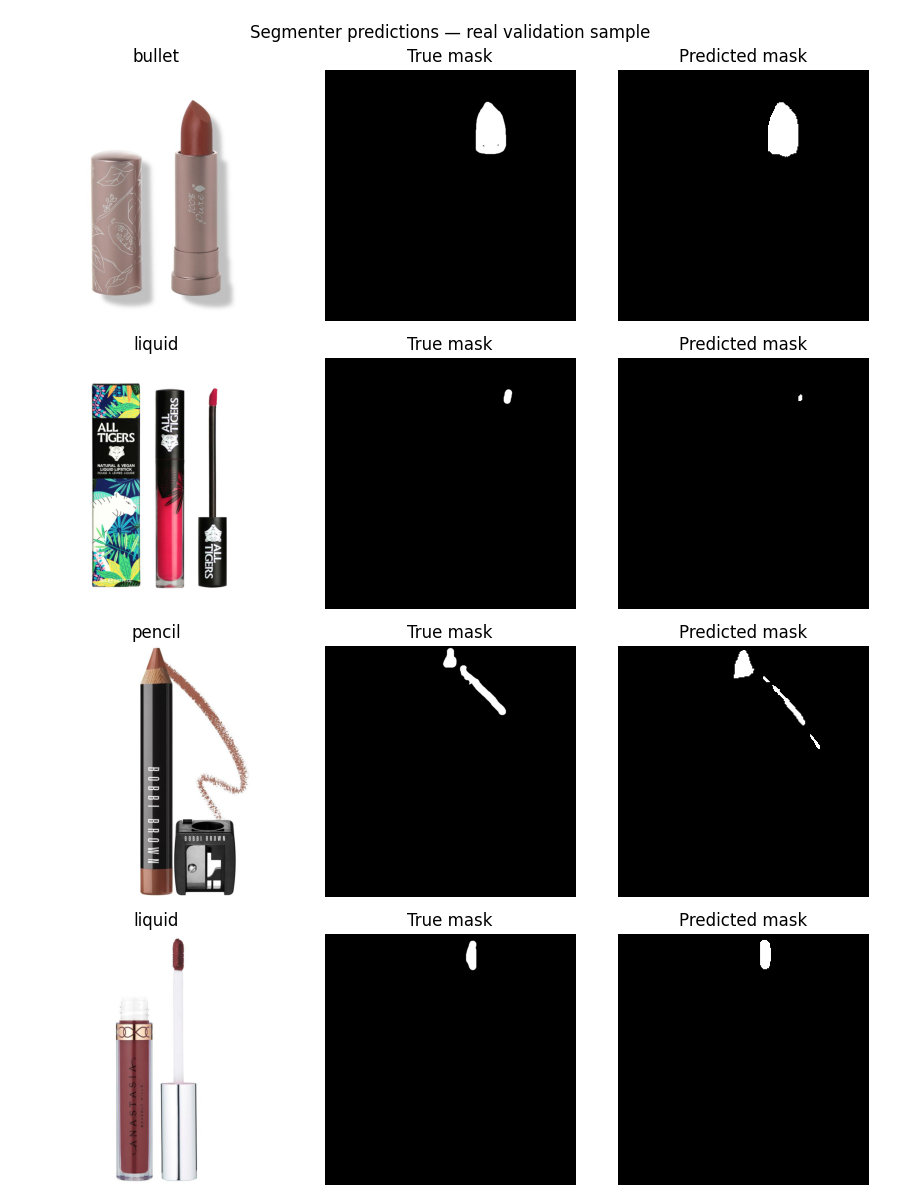

In [9]:
# Visualise a few real validation predictions: one bullet, one liquid, one
# pencil example (plus a 4th), each from a different brand so the sample
# can't accidentally collapse into near-duplicate photos of the same product.
candidates = labels_val_df[labels_val_df['label'].isin(SEG_CLASSES) & labels_val_df['img_name_disk'].notna()
                            & labels_val_df['mask_path'].apply(os.path.exists)].copy()
candidates['brand'] = candidates['img_name_disk'].str.split('__').str[1]

picks, seen_brands = [], set()
for lbl in SEG_CLASSES:
    # First unused-brand example of this class.
    pool = candidates[(candidates['label'] == lbl) & (~candidates['brand'].isin(seen_brands))]
    row = pool.iloc[0]
    picks.append(row)
    seen_brands.add(row['brand'])
# 4th slot: one more example, still from a brand not already picked.
extra_pool = candidates[~candidates['brand'].isin(seen_brands)]
picks.append(extra_pool.iloc[0])
sample = pd.DataFrame(picks).reset_index(drop=True)

# Image / ground-truth mask / predicted mask, side by side, one row per example.
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, row in sample.iterrows():
    img_path = find_image(row['img_name_disk'], img_dirs=(VAL_IMG_DIR,))
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title(row['label'])
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Segmenter predictions — real validation sample')
plt.tight_layout()
plt.show()


### Stage 2b: Color Region Segmenter for `closed` (Transparent Containers)

`closed` images (transparent containers) have hand-drawn masks highlighting the visible color through the packaging: the same annotation format as bullet/liquid. A separate U-Net is trained on these images so color can be extracted the same way as the other classes.

Same architecture and training procedure as Stage 2a; saved to `models/unet_segmenter_other.pth`.

In [10]:
# Rows usable for the `closed` segmenter: right label, image found on disk,
# and a real hand-drawn mask exists.
other_df = labels_df[(labels_df['label'] == 'closed') & labels_df['img_name_disk'].notna()
                      & labels_df['mask_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Other seg — train: {len(other_df)}  (100% of eligible data, no internal val split)')

seed_everything()
seg_other_train_ds = SegDatasetAny(other_df, augment=True, rotation_range=45)  # adopted, see Stage 2a note

# Warm-start from bullet/liquid segmenter — encoder + decoder already tuned to lipstick images
seg_other = build_segmenter().to(DEVICE)
seg_other.load_state_dict(torch.load(seg_ckpt, map_location=DEVICE)['model_state_dict'])
print('Warm-started from unet_segmenter.pth')

crit_seg_other = nn.BCEWithLogitsLoss()
opt_seg_other  = torch.optim.Adam(seg_other.parameters(), lr=1e-4)
seg_other_ckpt = os.path.join(MODELS_DIR, 'unet_segmenter_other.pth')

# Standard supervised training loop, fixed 20 epochs, no internal val split
# (same rationale as train_seg_model above — real IoU is checked afterward).
for epoch in range(20):
    seg_other.train()
    for imgs, masks in DataLoader(seg_other_train_ds, batch_size=16, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = crit_seg_other(seg_other(imgs), masks)
        opt_seg_other.zero_grad(); loss.backward(); opt_seg_other.step()

torch.save({'model_state_dict': seg_other.state_dict()}, seg_other_ckpt)
seg_other.eval()
iou_other, n_iou_other = eval_iou_on_val(seg_other, labels_val_df, 'closed')
print(f'Real validation IoU (labels_val.csv, N={n_iou_other}): {iou_other:.4f}  \u2192  {seg_other_ckpt}')


Other seg — train: 39  (100% of eligible data, no internal val split)


Warm-started from unet_segmenter.pth


Real validation IoU (labels_val.csv, N=12): 0.7342  →  /Users/connie/dev/lipstick_color_extraction/models/unet_segmenter_other.pth


Initial training on `closed` images (ImageNet weights, no augmentation) produced loose, imprecise masks: the model found the general region but failed to follow the color boundary tightly. Two changes improved this:

1. **Warm start from `unet_segmenter.pth`**: instead of starting from generic ImageNet weights, the model is initialized with the bullet/liquid segmenter's weights. Both encoder and decoder have already learned what a lipstick color-region mask looks like, giving a much better starting point.
2. **Synchronized augmentation**: horizontal flip, vertical flip, and ±45° rotation are applied identically to the image and mask during training (see Design Decisions above). With only 39 training images, this significantly increases the effective diversity seen by the model.

The real validation sample below shows the predicted mask aligning tightly with the ground-truth mask after these changes.

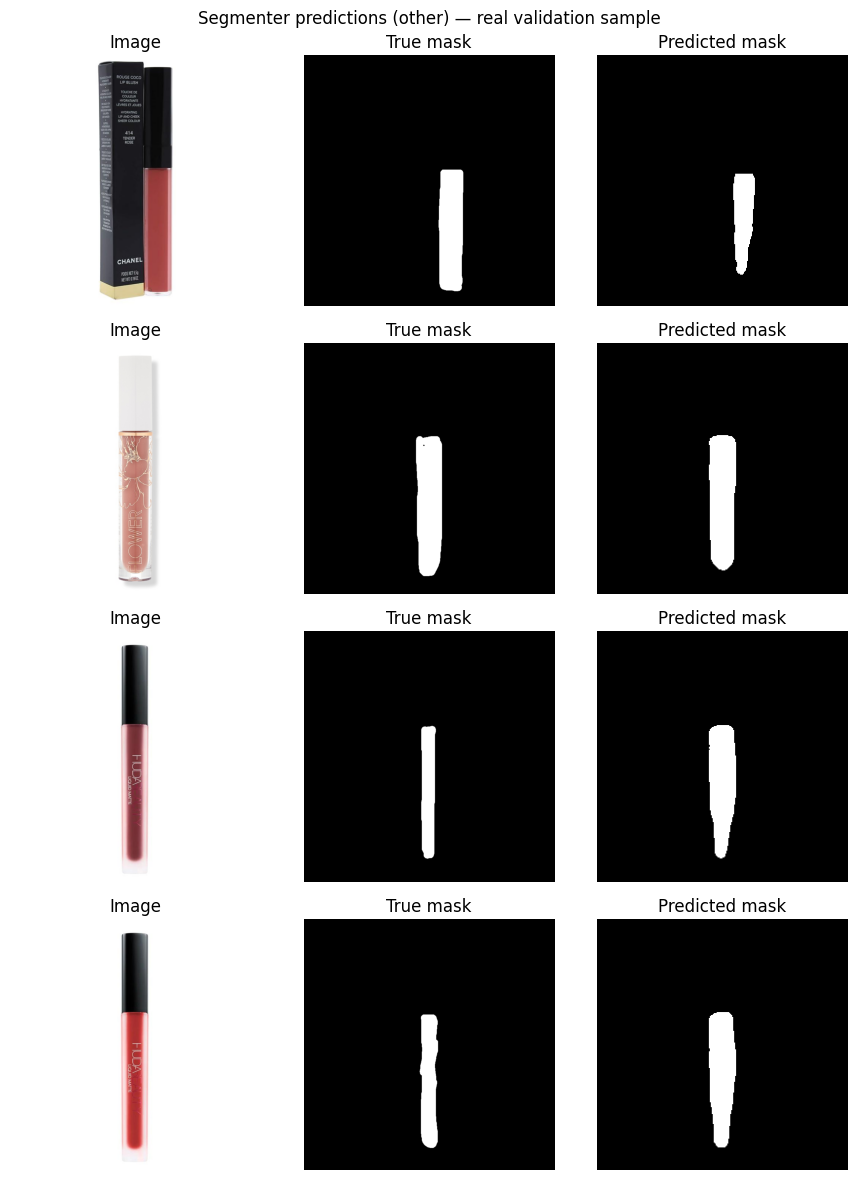

In [11]:
# Visualise a few real validation predictions for `closed`.
sample_other = labels_val_df[(labels_val_df['label'] == 'closed') & labels_val_df['img_name_disk'].notna()
                              & labels_val_df['mask_path'].apply(os.path.exists)].head(4).reset_index(drop=True)
fig, axes = plt.subplots(len(sample_other), 3, figsize=(9, 3 * len(sample_other)))
axes = np.array(axes).reshape(len(sample_other), 3)
for i, row in sample_other.iterrows():
    img_path = find_image(row['img_name_disk'], img_dirs=(VAL_IMG_DIR,))
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_other(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Segmenter predictions (other) — real validation sample')
plt.tight_layout()
plt.show()


### Stage 2d: Color Region Segmenter for `swatch`

It is unclear whether swatches require full segmentation or whether a simpler approach — such as filtering pixels by lightness threshold — would be sufficient for accurate color extraction. To establish a benchmark and keep the pipeline consistent across product types, we train a U-Net segmenter on all 123 annotated swatch images using the same architecture as Stage 2a.

**Improving segmentation quality:** An initial run without augmentation reached IoU 0.9049. Adding synchronized augmentation (random horizontal flips and small rotations) and extending training to 40 epochs improved on that further (see Design Decisions above for the current numbers).

In [12]:
# Rows usable for the `swatch` segmenter: right label, image found on disk,
# and a real hand-drawn mask exists.
swatch_df = labels_df[(labels_df['label'] == 'swatch') & labels_df['img_name_disk'].notna()
                       & labels_df['mask_path'].apply(os.path.exists)]
print(f'Swatch seg — train: {len(swatch_df)}  (100% of eligible data, no internal val split)')

# Train from scratch (no warm start needed — swatches have the most training
# data of any class), then score for real against validation swatches.
seed_everything()
swatch_ckpt = os.path.join(MODELS_DIR, 'unet_swatch.pth')
seg_swatch = train_seg_model(
    swatch_df, None, swatch_ckpt, n_epochs=40, augment=True, rotation_range=45
)  # adopted, see Stage 2a note
iou_swatch, n_iou_swatch = eval_iou_on_val(seg_swatch, labels_val_df, 'swatch')
print(f'Real validation IoU (labels_val.csv, N={n_iou_swatch}): {iou_swatch:.4f}  \u2192  {swatch_ckpt}')


Swatch seg — train: 123  (100% of eligible data, no internal val split)


Trained 40 epochs on 100% of data  →  /Users/connie/dev/lipstick_color_extraction/models/unet_swatch.pth


Real validation IoU (labels_val.csv, N=170): 0.8844  →  /Users/connie/dev/lipstick_color_extraction/models/unet_swatch.pth


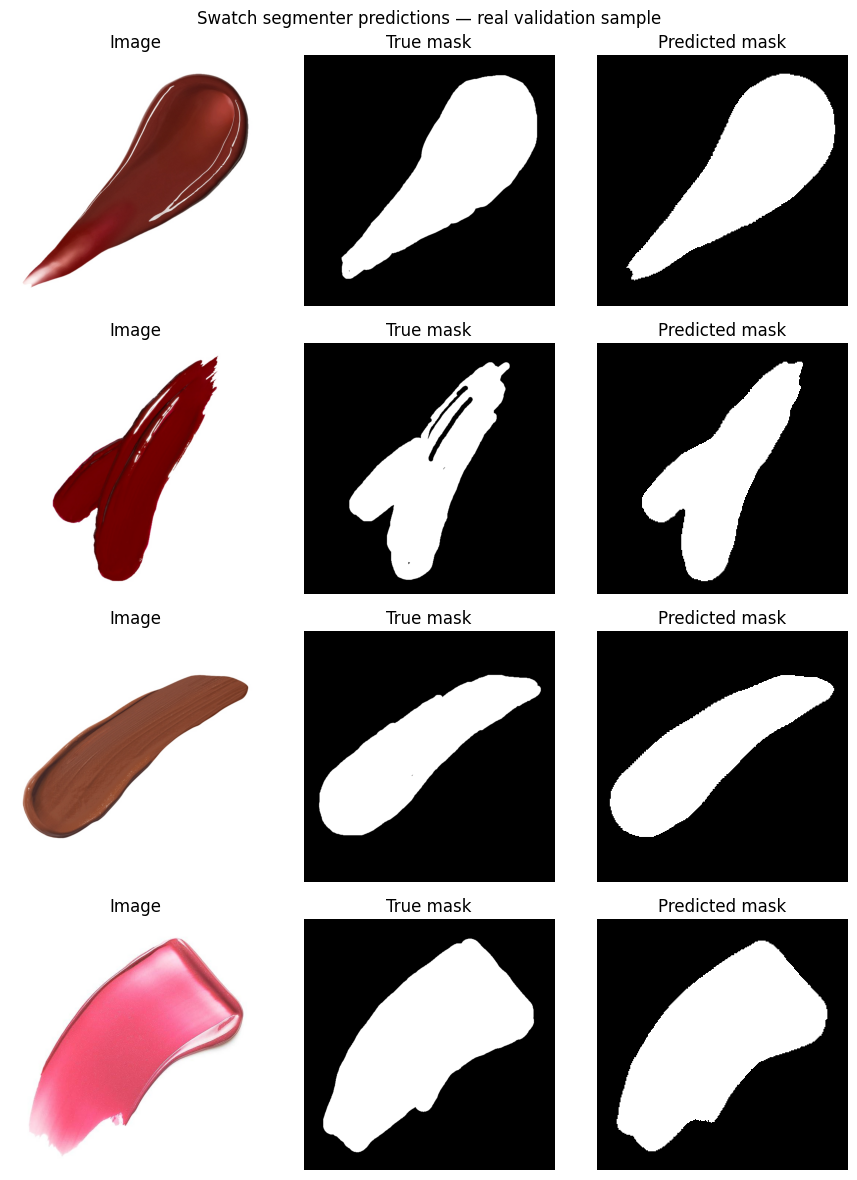

In [13]:
# Visualise a few real validation predictions for `swatch`.
sample_swatch = labels_val_df[(labels_val_df['label'] == 'swatch') & labels_val_df['img_name_disk'].notna()
                               & labels_val_df['mask_path'].apply(os.path.exists)].head(4).reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, row in sample_swatch.iterrows():
    img = Image.open(find_image(row['img_name_disk'], img_dirs=(VAL_IMG_DIR,))).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_swatch(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Swatch segmenter predictions — real validation sample')
plt.tight_layout()
plt.show()


### Stage 2e: Color Region Segmenter for `lips`

`lips` started Round 3 with 3 examples, too few for any train/val split, so the first version of this model force-trained on all 3 with no way to measure real quality. Round 4's oversampling brought it to 19 labeled; Round 5 then corrected one mislabeled image (task 332, a swatch photo of a lip-tint product) from `lips` back to `pencil`, leaving 18 labeled, 16 unique after de-duplicating shared retailer photos. Trained on all 16, the same point `closed` was upgraded from a force-trained bootstrap to a validated model. Still warm-started from the combined `bullet`/`liquid`/`pencil` segmenter, same trick Stage 2b used for `closed`.

In [14]:
lips_df = labels_df[(labels_df['label'] == 'lips') & labels_df['img_name_disk'].notna()
                     & labels_df['mask_path'].apply(os.path.exists)].reset_index(drop=True)

# A handful of catalog rows share one retailer photo across multiple shade
# listings (seen elsewhere in this catalog too; see the L'Oreal writeup).
# De-duplicate by image content so the model doesn't train on the same photo twice.
def _content_hash(img_name):
    """MD5 hash of the image file's bytes, used to detect rows that point to
    the same underlying retailer photo despite different filenames."""
    with open(find_image(img_name), 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()
n_before_dedup = len(lips_df)
lips_df = (lips_df.assign(_hash=lips_df['img_name_disk'].apply(_content_hash))
                   .drop_duplicates(subset='_hash')
                   .drop(columns='_hash')
                   .reset_index(drop=True))
print(f'lips images available: {len(lips_df)} (deduplicated from {n_before_dedup}; some rows share one retailer photo)')
print(f'Lips seg — train: {len(lips_df)}  (100% of eligible data, no internal val split)')

seed_everything()
lips_ckpt = os.path.join(MODELS_DIR, 'unet_lips.pth')

# Warm-started from the combined bullet/liquid/pencil segmenter, same trick Stage 2b used for `closed`.
seg_lips = build_segmenter().to(DEVICE)
seg_lips.load_state_dict(torch.load(seg_ckpt, map_location=DEVICE)['model_state_dict'])
print('Warm-started from unet_segmenter.pth')

crit_lips = nn.BCEWithLogitsLoss()
opt_lips  = torch.optim.Adam(seg_lips.parameters(), lr=1e-4)
lips_train_ds = SegDatasetAny(lips_df, augment=True, rotation_range=45)  # adopted, see Stage 2a note

# Standard supervised training loop, fixed 30 epochs, batch size 8 (small
# because there are only 16 training images).
for epoch in range(30):
    seg_lips.train()
    for imgs, masks in DataLoader(lips_train_ds, batch_size=8, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = crit_lips(seg_lips(imgs), masks)
        opt_lips.zero_grad(); loss.backward(); opt_lips.step()

torch.save({'model_state_dict': seg_lips.state_dict()}, lips_ckpt)
seg_lips.eval()
iou_lips, n_iou_lips = eval_iou_on_val(seg_lips, labels_val_df, 'lips')
print(f'Real validation IoU (labels_val.csv, N={n_iou_lips}): {iou_lips:.4f}  \u2192  {lips_ckpt}')


lips images available: 16 (deduplicated from 18; some rows share one retailer photo)
Lips seg — train: 16  (100% of eligible data, no internal val split)


Warm-started from unet_segmenter.pth


Real validation IoU (labels_val.csv, N=11): 0.8431  →  /Users/connie/dev/lipstick_color_extraction/models/unet_lips.pth


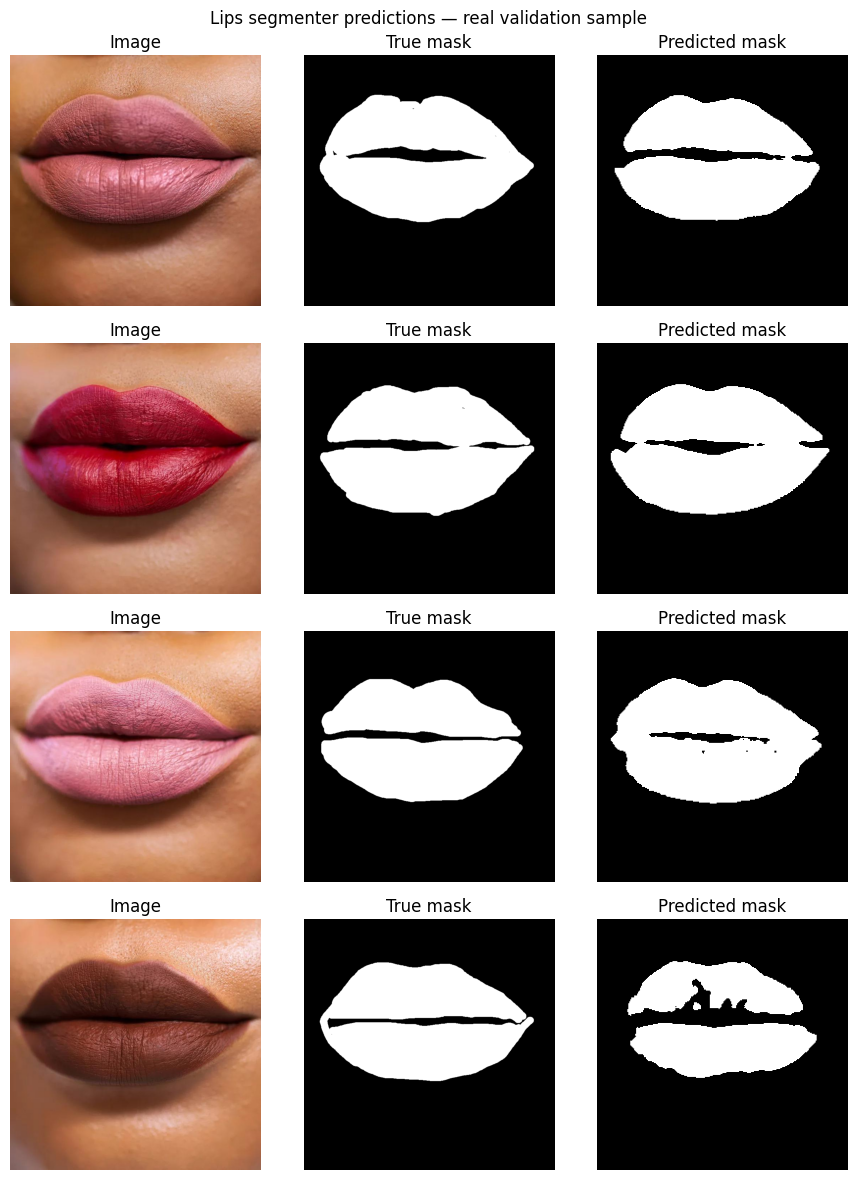

In [15]:
# Visualise a few real validation predictions for `lips`.
sample_lips = labels_val_df[(labels_val_df['label'] == 'lips') & labels_val_df['img_name_disk'].notna()
                             & labels_val_df['mask_path'].apply(os.path.exists)].head(4).reset_index(drop=True)
fig, axes = plt.subplots(len(sample_lips), 3, figsize=(9, 3 * len(sample_lips)))
axes = np.array(axes).reshape(len(sample_lips), 3)
for i, row in sample_lips.iterrows():
    img_path = find_image(row['img_name_disk'], img_dirs=(VAL_IMG_DIR,))
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_lips(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Lips segmenter predictions — real validation sample')
plt.tight_layout()
plt.show()


## Track segmentation results over time

Append each segmenter's result to a small CSV log, one row per training run,
so future changes (like the rotation-range experiment above) can be compared
against real history instead of relying on notebook diffs, which get noisy
fast for a file this size.


In [16]:
# Record each segmenter's config + real validation IoU as one row, appended
# to a running history CSV (see the Design Decisions note above for the
# ±15°/±45° rotation-range story this log was built to track).
import datetime

log_path = os.path.join(BASE, 'notebooks', 'segmentation_results_log.csv')
today = datetime.date.today().isoformat()

log_rows = [
    {'date': today, 'segmenter': 'bullet_liquid_pencil', 'rotation_range_deg': 45,
     'epochs': 60, 'n_train': len(seg_train_df), 'n_val': n_iou_seg,
     'iou': round(iou_seg, 4), 'status': 'adopted (unet_segmenter.pth); trained on 100% of data, IoU on real labels_val.csv'},
    {'date': today, 'segmenter': 'closed', 'rotation_range_deg': 45,
     'epochs': 20, 'n_train': len(other_df), 'n_val': n_iou_other,
     'iou': round(iou_other, 4), 'status': 'adopted (unet_segmenter_other.pth); trained on 100% of data, IoU on real labels_val.csv'},
    {'date': today, 'segmenter': 'swatch', 'rotation_range_deg': 45,
     'epochs': 40, 'n_train': len(swatch_df), 'n_val': n_iou_swatch,
     'iou': round(iou_swatch, 4), 'status': 'adopted (unet_swatch.pth); trained on 100% of data, IoU on real labels_val.csv'},
    {'date': today, 'segmenter': 'lips', 'rotation_range_deg': 45,
     'epochs': 30, 'n_train': len(lips_df), 'n_val': n_iou_lips,
     'iou': round(iou_lips, 4), 'status': 'adopted (unet_lips.pth); trained on 100% of data, IoU on real labels_val.csv'},
]
log_df = pd.DataFrame(log_rows)

write_header = not os.path.exists(log_path)
log_df.to_csv(log_path, mode='a', header=write_header, index=False)
print(f'Appended {len(log_df)} rows to {log_path}')
log_df


Appended 4 rows to /Users/connie/dev/lipstick_color_extraction/notebooks/segmentation_results_log.csv


,date,segmenter,rotation_range_deg,epochs,n_train,n_val,iou,status
0,2026-09-17,bullet_liquid_pencil,45,60,171,254,0.7240,adopted (unet_segmenter.pth); trained on 100% ...
1,2026-09-17,closed,45,20,39,12,0.7342,adopted (unet_segmenter_other.pth); trained on...
2,2026-09-17,swatch,45,40,123,170,0.8844,adopted (unet_swatch.pth); trained on 100% of ...
3,2026-09-17,lips,45,30,16,11,0.8431,adopted (unet_lips.pth); trained on 100% of da...
